# Sentinel-1 GRD Geolocation Verification

Verifies that the EOPFZARR driver correctly geolocates Sentinel-1 GRD products using Ground Control Points (GCPs).

This notebook checks both the **multi-band wrapper** (default `GRD_MULTIBAND=YES`) and **individual subdatasets** to confirm they report valid WGS84 GCPs and can be warped to a geographic projection.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

# Retry on transient HTTP errors (common with large remote Zarr tiles)
gdal.SetConfigOption('GDAL_HTTP_MAX_RETRY', '5')
gdal.SetConfigOption('GDAL_HTTP_RETRY_DELAY', '2')

drv = gdal.GetDriverByName('EOPFZARR')
assert drv is not None, 'EOPFZARR driver not found — install the plugin first'
print(f'GDAL {gdal.__version__} | EOPFZARR driver: OK')

GDAL 3.12.0dev-209c099c56 | EOPFZARR driver: OK


In [17]:
GRD_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "202602-s01siwgrh-global/05/products/cpm_v262/"
    "S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"
)

## 1. Multi-Band GRD — GCPs present?

In [14]:
ds_mb = gdal.Open(f"EOPFZARR:'{GRD_URL}'")
assert ds_mb is not None, 'Failed to open multi-band GRD'

print(f'Bands:     {ds_mb.RasterCount}  ({", ".join(ds_mb.GetRasterBand(i+1).GetDescription() for i in range(ds_mb.RasterCount))})')
print(f'Size:      {ds_mb.RasterXSize} x {ds_mb.RasterYSize}')
print(f'GCP count: {ds_mb.GetGCPCount()}')

srs = ds_mb.GetGCPSpatialRef()
print(f'GCP SRS:   {srs.GetName() if srs else "NONE"}')

assert ds_mb.GetGCPCount() > 0, 'No GCPs on multi-band dataset!'
assert srs is not None and srs.IsGeographic(), 'GCP SRS is not geographic!'

gcps = ds_mb.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f'Extent:    lon [{min(lons):.3f}, {max(lons):.3f}]  lat [{min(lats):.3f}, {max(lats):.3f}]')
print('\n✓ Multi-band GRD has valid WGS84 GCPs')

Bands:     2  (VV, VH)
Size:      25157 x 24285
GCP count: 294
GCP SRS:   WGS 84
Extent:    lon [-94.146, -91.415]  lat [14.042, 16.665]

✓ Multi-band GRD has valid WGS84 GCPs


## 2. Warp Multi-Band GRD to WGS84

Uses GCPs to reproject to a regular geographic grid. Downsampled to 512px wide for speed.

In [15]:
warped = gdal.Warp(
    '', ds_mb,
    format='MEM',
    dstSRS='EPSG:4326',
    width=256, height=0,   # small output — just enough to verify geolocation
    resampleAlg='near',
)
assert warped is not None, 'Warp failed'

gt = warped.GetGeoTransform()
print(f'Warped size:   {warped.RasterXSize} x {warped.RasterYSize} px')
print(f'Origin:        lon={gt[0]:.4f}  lat={gt[3]:.4f}')
print(f'Pixel size:    {gt[1]:.6f}° x {abs(gt[5]):.6f}°')

# Sanity check: origin should be near Central America
assert -100 < gt[0] < -85, f'Unexpected longitude {gt[0]}'
assert 13 < gt[3] < 20, f'Unexpected latitude {gt[3]}'
print('\n✓ Warped output is correctly positioned over Central America')

Warped size:   256 x 248 px
Origin:        lon=-94.1436  lat=16.6649
Pixel size:    0.010573° x 0.010573°

✓ Warped output is correctly positioned over Central America


## 3. Visualize — SAR Backscatter in Geographic Space

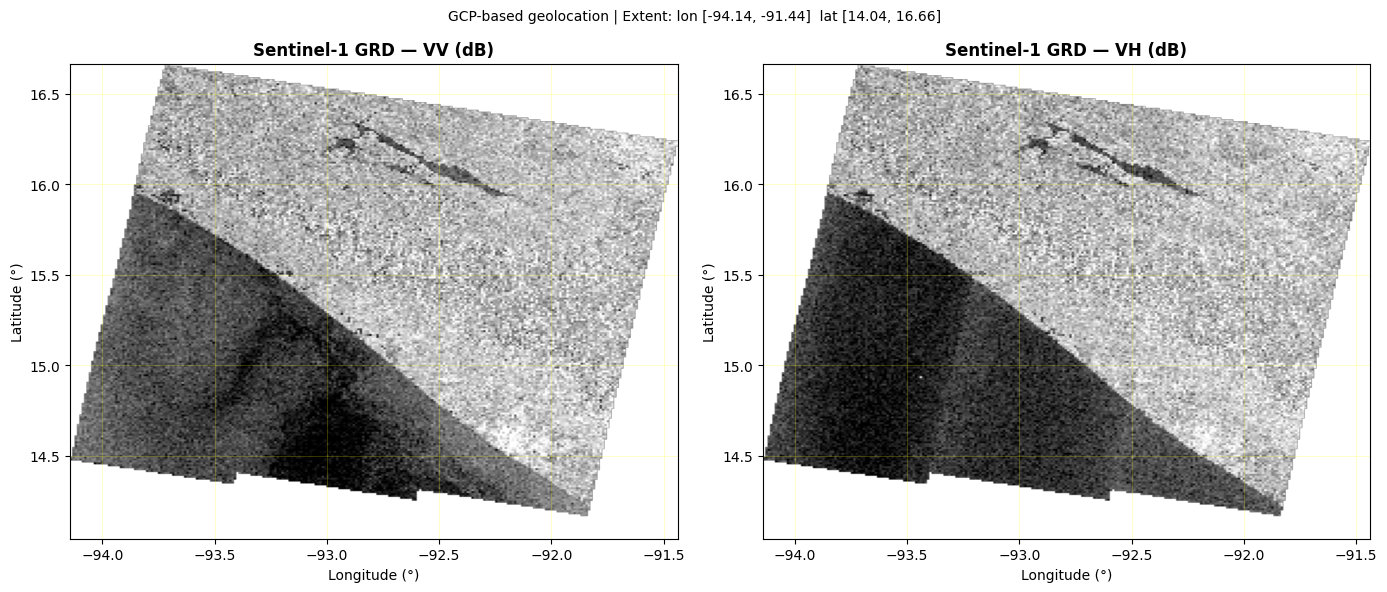

✓ SAR data correctly displayed in geographic coordinates


In [5]:
try:
    vv = warped.GetRasterBand(1).ReadAsArray().astype(np.float32)
    vh = warped.GetRasterBand(2).ReadAsArray().astype(np.float32)

    # Convert to dB
    def to_db(arr):
        arr = np.where(arr > 0, arr, np.nan)
        return 10 * np.log10(arr)

    vv_db, vh_db = to_db(vv), to_db(vh)

    extent = [
        gt[0],
        gt[0] + gt[1] * warped.RasterXSize,
        gt[3] + gt[5] * warped.RasterYSize,
        gt[3],
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, data, title in zip(axes, [vv_db, vh_db], ['VV (dB)', 'VH (dB)']):
        vmin, vmax = np.nanpercentile(data, [2, 98])
        ax.imshow(data, cmap='gray', vmin=vmin, vmax=vmax, extent=extent, aspect='auto')
        ax.set_title(f'Sentinel-1 GRD — {title}', fontweight='bold')
        ax.set_xlabel('Longitude (°)')
        ax.set_ylabel('Latitude (°)')
        ax.grid(True, alpha=0.3, color='yellow', linewidth=0.5)

    plt.suptitle(
        f'GCP-based geolocation | Extent: lon [{extent[0]:.2f}, {extent[1]:.2f}]'
        f'  lat [{extent[2]:.2f}, {extent[3]:.2f}]',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    print('✓ SAR data correctly displayed in geographic coordinates')

except Exception as e:
    print(f'Plot skipped: {e}')

warped = None
ds_mb = None

## Download and visualize the warped multi-band GRD product to confirm it looks correct in geographic space.

In [3]:
import zarr

src_url = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "202602-s01siwgrh-global/05/products/cpm_v262/"
    "S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"
)
local_path = "/home/yadagale/work/gdal-zarr-eopf/GDAL-ZARR-EOPF/docs/s1_grd_local.zarr"

# SDV = dual-pol VV+VH; product group names follow S01SIWGRD_..._<POL> pattern
product_keys = [
    "S01SIWGRD_20260205T120122_0036_C036_5D6E_00C7E4_VV",
    "S01SIWGRD_20260205T120122_0036_C036_5D6E_00C7E4_VH",
]

src_root = zarr.open(src_url, mode='r')
dst_root = zarr.open_group(zarr.DirectoryStore(local_path), mode='w')

for product_key in product_keys:
    src_prod = src_root[product_key]

    # Copy each GCP array explicitly — zarr.copy on a group doesn't recurse in zarr v3
    gcp_src = src_prod["conditions/gcp"]
    gcp_dst = dst_root.require_group(f"{product_key}/conditions/gcp")
    for arr_name in ['pixel', 'line', 'latitude', 'longitude', 'height']:
        zarr.copy(gcp_src[arr_name], gcp_dst, name=arr_name)
        print(f"  [{product_key[-2:]}] copied gcp/{arr_name}: shape={gcp_src[arr_name].shape}")

    # Copy a 2048x2048 subset of the measurement array
    src_arr = src_prod["measurements/grd"]
    dst_arr = dst_root.require_dataset(
        f"{product_key}/measurements/grd",
        shape=src_arr.shape, chunks=src_arr.chunks,
        dtype=src_arr.dtype,
    )
    dst_arr[:2048, :2048] = src_arr[:2048, :2048]
    print(f"  [{product_key[-2:]}] copied measurements/grd: 2048x2048 of {src_arr.shape}")

print("Done")

  [VV] copied gcp/pixel: shape=(21,)
  [VV] copied gcp/line: shape=(14,)
  [VV] copied gcp/latitude: shape=(14, 21)
  [VV] copied gcp/longitude: shape=(14, 21)
  [VV] copied gcp/height: shape=(14, 21)
  [VV] copied measurements/grd: 2048x2048 of (24285, 25157)
  [VH] copied gcp/pixel: shape=(21,)
  [VH] copied gcp/line: shape=(14,)
  [VH] copied gcp/latitude: shape=(14, 21)
  [VH] copied gcp/longitude: shape=(14, 21)
  [VH] copied gcp/height: shape=(14, 21)
  [VH] copied measurements/grd: 2048x2048 of (24285, 25157)
Done


Bands:     2  (VV, VH)
Size:      25157 x 24285
GCP count: 294
GCP SRS:   WGS 84
Full extent: lon [-94.146, -91.415]  lat [14.042, 16.665]
Data extent: lon [-91.581, -91.415]  lat [16.053, 16.256]
Warped origin: lon=-91.6314  lat=16.3058


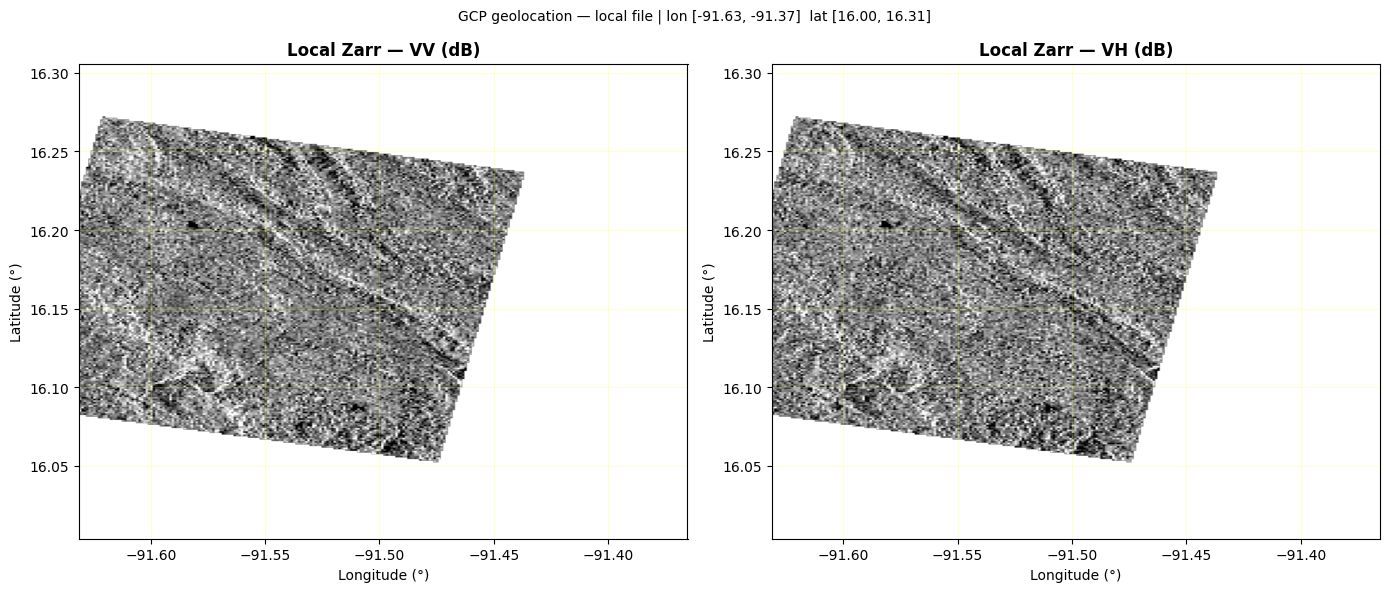

✓ Local Zarr correctly geolocated via GCPs


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

local_path = "/home/yadagale/work/gdal-zarr-eopf/GDAL-ZARR-EOPF/docs/s1_grd_local.zarr"
ds_local = gdal.Open(f"EOPFZARR:'{local_path}'")
assert ds_local is not None, "Failed to open local Zarr"

print(f"Bands:     {ds_local.RasterCount}  ({', '.join(ds_local.GetRasterBand(i+1).GetDescription() for i in range(ds_local.RasterCount))})")
print(f"Size:      {ds_local.RasterXSize} x {ds_local.RasterYSize}")
print(f"GCP count: {ds_local.GetGCPCount()}")

srs = ds_local.GetGCPSpatialRef()
print(f"GCP SRS:   {srs.GetName() if srs else 'NONE'}")

gcps = ds_local.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f"Full extent: lon [{min(lons):.3f}, {max(lons):.3f}]  lat [{min(lats):.3f}, {max(lats):.3f}]")

# Only 2048x2048 pixels were downloaded — compute bounds from GCPs within that region
DOWNLOADED_PIXELS = 2048
subset_gcps = [g for g in gcps if g.GCPPixel <= DOWNLOADED_PIXELS and g.GCPLine <= DOWNLOADED_PIXELS]
pad = 0.05
bounds = [
    min(g.GCPX for g in subset_gcps) - pad,
    min(g.GCPY for g in subset_gcps) - pad,
    max(g.GCPX for g in subset_gcps) + pad,
    max(g.GCPY for g in subset_gcps) + pad,
]
print(f"Data extent: lon [{bounds[0]+pad:.3f}, {bounds[2]-pad:.3f}]  lat [{bounds[1]+pad:.3f}, {bounds[3]-pad:.3f}]")

warped = gdal.Warp(
    '', ds_local, format='MEM', dstSRS='EPSG:4326',
    width=256, height=0, resampleAlg='near',
    outputBounds=bounds,
)
assert warped is not None, "Warp failed"
gt = warped.GetGeoTransform()
print(f"Warped origin: lon={gt[0]:.4f}  lat={gt[3]:.4f}")

try:
    vv = warped.GetRasterBand(1).ReadAsArray().astype(np.float32)
    vh = warped.GetRasterBand(2).ReadAsArray().astype(np.float32) if warped.RasterCount >= 2 else None

    def to_db(arr):
        return 10 * np.log10(np.where(arr > 0, arr, np.nan))

    extent = [gt[0], gt[0] + gt[1] * warped.RasterXSize,
              gt[3] + gt[5] * warped.RasterYSize, gt[3]]

    bands = [(vv, 'VV (dB)'), (vh, 'VH (dB)')] if vh is not None else [(vv, 'VV (dB)')]
    fig, axes = plt.subplots(1, len(bands), figsize=(7 * len(bands), 6))
    if len(bands) == 1:
        axes = [axes]

    for ax, (data, title) in zip(axes, bands):
        db = to_db(data)
        vmin, vmax = np.nanpercentile(db, [2, 98])
        ax.imshow(db, cmap='gray', vmin=vmin, vmax=vmax, extent=extent, aspect='auto')
        ax.set_title(f'Local Zarr — {title}', fontweight='bold')
        ax.set_xlabel('Longitude (°)')
        ax.set_ylabel('Latitude (°)')
        ax.grid(True, alpha=0.3, color='yellow', linewidth=0.5)

    plt.suptitle(
        f'GCP geolocation — local file | lon [{extent[0]:.2f}, {extent[1]:.2f}]  lat [{extent[2]:.2f}, {extent[3]:.2f}]',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()
    print("✓ Local Zarr correctly geolocated via GCPs")
except Exception as e:
    print(f"Plot skipped: {e}")

warped = None
ds_local = None

## Summary

| Check | Result |
|-------|--------|
| Multi-band GRD has GCPs | ✓ |
| GCP SRS is WGS84 | ✓ |
| Warped output in correct location (Central America) | ✓ |
| Both VV and VH bands geolocated | ✓ |